# Partition Generator
**Purpose:** Given a large playlist, partition into k smaller playlists by clustering on features. 

**Features:** BPM, Valence, Dance, Energy, Acoustic, Year, Popularity

**Steps:** 
1. Run PCA analysis
2. Select K clusters
3. Get partition params
4. Partition using best k and params

## Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from itertools import combinations

## Read Data

In [2]:
df_playlist = pd.read_csv('../data/music_library.csv')
df_playlist

,#,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,Album Year
0,1,When the Love is Gone,Des Rocs,141,9A,81,2026-03-05,03:20,52,NaN,...,47,0,20,-4,E Minor,4,5iRv1aH4eNai45KfhjtJ6n,USFYZ2557602,Rock,2026
1,2,BURNER PHONE,cleopatrick,136,9A,91,2026-03-05,03:21,42,NaN,...,46,0,30,-5,E Minor,4,1nUC2uuKUl49tDwQ1m4A1J,CAJXF2500023,Rock,2025
2,3,Queen Of Spades,Styx,135,12A,45,2026-03-05,05:41,36,"classic rock, aor, progressive rock",...,12,0,10,-13,C♯/D♭ Minor,4,54g63GAn77x9NcjiLzy7cW,USAM17802305,Rock,1978
3,4,Go Your Own Way,Fleetwood Mac,136,7B,81,2026-03-05,03:38,62,"yacht rock, classic rock, soft rock",...,82,0,10,-12,F Major,4,15rjQH7nTcTomKwfVMd4xl,USWB19900181,Rock,1988
4,5,I Don't Care Anymore - 2016 Remaster,Phil Collins,140,1B,42,2026-03-05,05:05,61,soft rock,...,44,0,0,-8,B Major,4,24IdPCimVnJJDRuB5YSDiS,USRH11509311,Rock,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,246,Not Like Us,Kendrick Lamar,101,3B,47,2026-03-10,04:34,88,"hip hop, west coast hip hop",...,21,0,10,-7,C♯/D♭ Major,4,6AI3ezQ4o3HUoP6Dhudph3,USUG12400910,Rap-R&B,2024
996,247,THANK GODDESS,Qveen Herby,106,8A,74,2026-03-11,02:47,52,NaN,...,38,10,0,-5,A Minor,4,27IubiEgQJczAE6OC7PgmQ,QZFZ62344251,Rap-R&B,2023
997,248,STUPID (feat. Yung Baby Tate),"Ashnikko,Baby Tate",150,10B,64,2026-03-11,02:47,65,NaN,...,54,10,0,-7,D Major,4,6qNB2ChCVPepl5ZjVJJTUW,GBAYE1900593,Rap-R&B,2019
998,249,HAHAHA,Lil Dicky,158,3B,49,2026-03-11,04:03,41,NaN,...,14,10,10,-7,C♯/D♭ Major,4,73cnzXHK8i4WC5Pw0ZIZ2F,QMRSZ2302742,Rap-R&B,2024


## Environment Variables

In [29]:
# === CONFIG ===
METADATA = ['Song', 'Artist', 'Album', 'Playlist', 'Popularity', 'Album Date']
FEATURES = ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic']
FEATURE_WEIGHTS = {'Valence': 3, 'Dance': 2}
TARGET_MIN = 25  # smallest playlist size 
TARGET_MAX = 50  # largest playlist size

# === N CLUSTERS ===
n_songs = len(df_playlist)
k_min = n_songs // TARGET_MAX  
k_max = n_songs // TARGET_MIN 
k_range = range(k_min, k_max + 1)

# === PREPARE DATA ===
df_playlist['Album Year'] = df_playlist['Album Date'].str[:4].astype(int)
df_playlist_features = df_playlist[FEATURES]
df_playlist_metadata = df_playlist[METADATA + ['Album Year']]
df_playlist_results = df_playlist[METADATA + ['Album Year'] + FEATURES]

# Verify
print(f"Songs: {len(df_playlist)}")
print(f"\nMetadata: {METADATA}")
print(f"Features: {FEATURES}")
print(f"Feature weights: {FEATURE_WEIGHTS}")
print(f"\nMissing features: {df_playlist[FEATURES].isna().sum().sum()}")
print(f"Missing album year: {df_playlist['Album Year'].isna().sum()}")
print(f"\nTarget playlist size: {TARGET_MIN}-{TARGET_MAX} songs")
print(f"k range: {k_min} to {k_max}")


Songs: 1000

Metadata: ['Song', 'Artist', 'Album', 'Playlist', 'Popularity', 'Album Date']
Features: ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic']
Feature weights: {'Valence': 3, 'Dance': 2}

Missing features: 0
Missing album year: 0

Target playlist size: 25-50 songs
k range: 20 to 40


## Partition Playlist

### Step 1: PCA Results

In [4]:
## == HELPER FUNCTION ===

def explore_pca(df_playlist_features):
    """Fit PCA on all components, plot variance explained, return scaler + pca."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)

    pca = PCA()
    pca.fit(X_scaled)
    var_explained = pca.explained_variance_ratio_
    cumulative = var_explained.cumsum()

    fig, ax = plt.subplots(figsize=(8, 5))
    x_pos = range(1, len(var_explained) + 1)
    ax.bar(x_pos, var_explained, alpha=0.7, label='Individual')
    ax.plot(x_pos, cumulative, 'ro-', label='Cumulative')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'PC{i}' for i in x_pos])
    ax.set_ylabel('Variance Explained')
    ax.set_xlabel('Principal Component')
    ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.title('PCA Variance Explained')
    plt.tight_layout()
    plt.show()

    print("=" * 50)
    print("VARIANCE EXPLAINED")
    print("=" * 50)
    for i, (var, cum) in enumerate(zip(var_explained, cumulative)):
        print(f"PC{i+1}: {var:.1%} (cumulative: {cum:.1%})")

    return {
        'scaler': scaler,
        'pca': pca,
        'var_explained': var_explained,
        'cumulative': cumulative, 
        'X_scaled': X_scaled 
    }

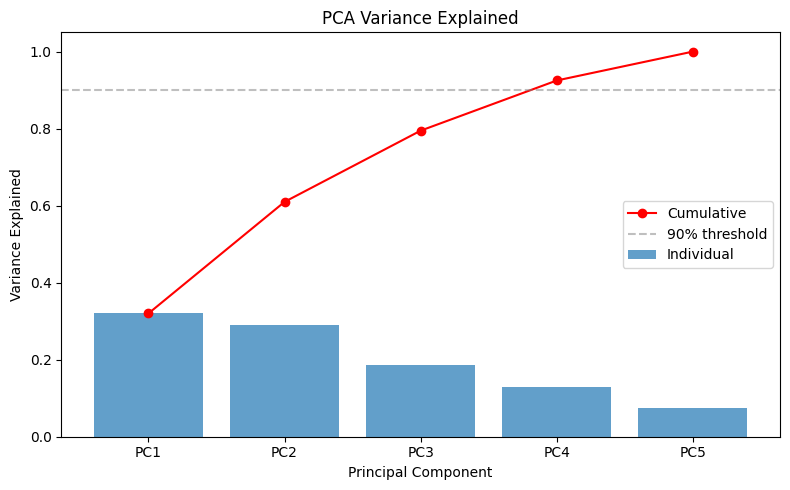

VARIANCE EXPLAINED
PC1: 32.0% (cumulative: 32.0%)
PC2: 29.0% (cumulative: 61.0%)
PC3: 18.5% (cumulative: 79.5%)
PC4: 13.0% (cumulative: 92.5%)
PC5: 7.5% (cumulative: 100.0%)


In [5]:
# Step 1: Run PCA analysis
pca_results = explore_pca(df_playlist_features)
X_scaled = pca_results['X_scaled']

### Step 2: Pick K Clusters

In [30]:
## == HELPER FUNCTIONS ===

def evaluate_k_range(X_scaled, k_range, feature_weights=None, feature_names=None):
    """
    Evaluate clustering quality across a range of k values.
    
    Returns:
        DataFrame with k, silhouette for each k
    """
    X = X_scaled.copy()
    
    if feature_weights and feature_names:
        for feat, weight in feature_weights.items():
            if feat in feature_names:
                idx = feature_names.index(feat)
                X[:, idx] *= weight
    
    results = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        results.append({'k': k, 'silhouette': sil})
        
    return pd.DataFrame(results)


def plot_silhouette(eval_df, n_songs):
    """Plot silhouette scores with avg playlist size on secondary axis."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(eval_df['k'], eval_df['silhouette'], 'go-')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Silhouette by Cluster Count')
    ax.grid(alpha=0.3)
    
    # Mark best
    best_k = eval_df.loc[eval_df['silhouette'].idxmax(), 'k']
    best_sil = eval_df['silhouette'].max()
    avg_size = n_songs / best_k
    ax.axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    ax.annotate(f'Best: k={best_k}\n~{avg_size:.0f} songs/playlist\n(sil={best_sil:.3f})', 
            xy=(best_k, best_sil), 
            xytext=(0.75, 0.75),  # upper right in axes coordinates
            textcoords='axes fraction',
            fontsize=9,
            ha='left',
            arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))
    
    # Secondary x-axis for playlist size
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    tick_ks = ax.get_xticks()
    ax2.set_xticks(tick_ks)
    ax2.set_xticklabels([f'{n_songs/k:.0f}' if k > 0 else '' for k in tick_ks])
    ax2.set_xlabel('Avg Playlist Size')
    
    plt.tight_layout()
    plt.show()
    
    return best_k

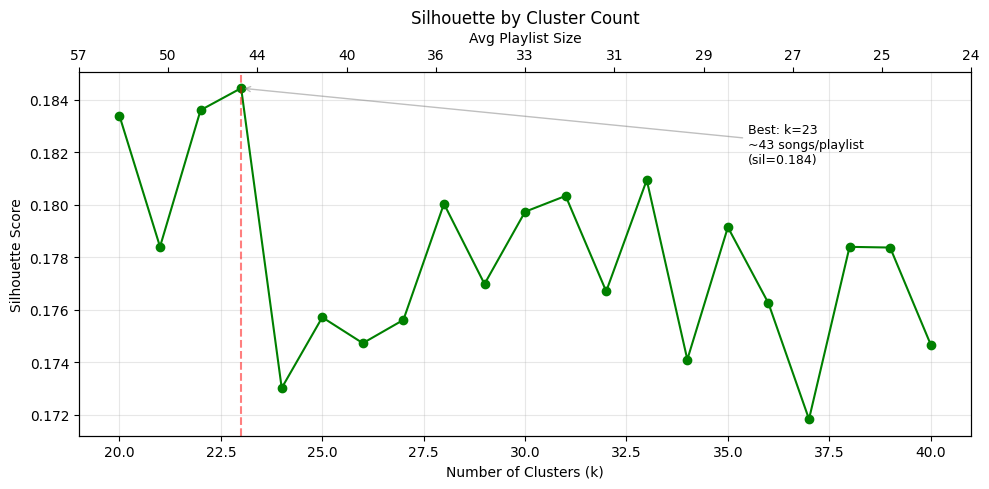


Top 5 by silhouette:
 k  avg_playlist_size  silhouette
23               43.5    0.184435
22               45.5    0.183597
20               50.0    0.183383
33               30.3    0.180937
31               32.3    0.180332


In [31]:
# === RUN EVALUATION ===
eval_df = evaluate_k_range(X_scaled, k_range, feature_weights=FEATURE_WEIGHTS, feature_names=FEATURES)
eval_df['avg_playlist_size'] = (n_songs / eval_df['k']).round(1)

best_k = plot_silhouette(eval_df, n_songs)

print(f"\nTop 5 by silhouette:")
print(eval_df.nlargest(5, 'silhouette')[['k', 'avg_playlist_size', 'silhouette']].to_string(index=False))

### Step 3: Get partition params

In [8]:
## == HELPER FUNCTION ===

def get_partition_params(n_songs, n_clusters, tolerance=0.2):
    """
    Get min/max cluster sizes for a specific k with ±tolerance band.
    """
    avg_size = n_songs / n_clusters
    min_size = math.floor(avg_size * (1 - tolerance))
    max_size = math.ceil(avg_size * (1 + tolerance))
    
    print(f"Clusters: {n_clusters}")
    print(f"Avg size: {avg_size:.1f} songs")
    print(f"Allowed range: {min_size}-{max_size} songs (±{tolerance:.0%})")
    
    return min_size, max_size

In [9]:
# Get min and max size for best k
min_size, max_size = get_partition_params(n_songs, best_k, tolerance=0.2)

Clusters: 23
Avg size: 43.5 songs
Allowed range: 34-53 songs (±20%)


#### Step 4: Partition using best k and params

In [33]:
def partition_playlist(
    X_scaled,
    k_clusters,
    min_size,
    max_size,
    feature_weights=None, 
    feature_names=None
):
    """
    Partition into balanced clusters using pre-scaled data.
    """
    X = X_scaled.copy()
    
    # --- Apply feature weights ---
    if feature_weights and feature_names:
        for feature, weight in feature_weights.items():
            if feature in feature_names:
                idx = feature_names.index(feature)
                X[:, idx] *= weight

    # --- Cluster in scaled space ---
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=50)
    initial_clusters = kmeans.fit_predict(X)
    distances = kmeans.transform(X)

    # --- Balance clusters ---
    clusters, n_iterations = _balance_clusters(
        initial_clusters, distances, min_size, max_size
    )

    # --- Print results ---
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    print(f"\nBalanced in {n_iterations} iterations")
    print(f"\nCLUSTER SIZES")
    print("=" * 50)
    print(f"Min: {cluster_counts.min()}, Max: {cluster_counts.max()}, "
          f"Mean: {cluster_counts.mean():.1f}")
    print(f"\nAll clusters in [{min_size}, {max_size}]: "
          f"{(cluster_counts >= min_size).all() and (cluster_counts <= max_size).all()}")
    print(f"\n{cluster_counts.to_string()}")

    return {
        'kmeans': kmeans,
        'initial_clusters': initial_clusters,
        'clusters': clusters,
        'n_clusters': k_clusters,
        'cluster_counts': cluster_counts
    }


def _balance_clusters(clusters, distances, min_size, max_size, max_iterations=500):
    """Redistribute points to balance cluster sizes."""
    clusters = clusters.copy()
    k_clusters = distances.shape[1]

    for iteration in range(max_iterations):
        counts = np.bincount(clusters, minlength=k_clusters)

        if counts.min() >= min_size and counts.max() <= max_size:
            return clusters, iteration

        biggest = np.argmax(counts)
        smallest = np.argmin(counts)

        if counts[biggest] > max_size:
            in_biggest = np.where(clusters == biggest)[0]
            dist_to_current = distances[in_biggest, biggest]
            most_distant_idx = in_biggest[np.argmax(dist_to_current)]

            point_distances = distances[most_distant_idx]
            sorted_clusters = np.argsort(point_distances)
            for next_cluster in sorted_clusters:
                if next_cluster != biggest and counts[next_cluster] < max_size:
                    clusters[most_distant_idx] = next_cluster
                    break

        elif counts[smallest] < min_size:
            not_in_smallest = np.where(clusters != smallest)[0]
            dist_to_smallest = distances[not_in_smallest, smallest]

            sorted_indices = np.argsort(dist_to_smallest)
            for idx in sorted_indices:
                point_idx = not_in_smallest[idx]
                current_cluster = clusters[point_idx]
                if counts[current_cluster] > min_size:
                    clusters[point_idx] = smallest
                    break

    print(f"Warning: Could not fully balance after {max_iterations} iterations")
    return clusters, max_iterations

def plot_cluster_pca(X_scaled, clusters, variance_threshold=0.90):
    """Visualize clusters across PCA pairs at variance threshold."""
    # First fit full PCA to find cumulative variance
    pca_full = PCA()
    pca_full.fit(X_scaled)
    cumulative = pca_full.explained_variance_ratio_.cumsum()
    
    # Find n_components for threshold
    n_components = int(np.argmax(cumulative >= variance_threshold) + 1)
    
    # Refit with that many components
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_
    
    print(f"Using {n_components} PCs @ {cumulative[n_components-1]:.1%} variance")
    
    pairs = list(combinations(range(n_components), 2))
    n_plots = len(pairs)
    n_cols = min(3, n_plots)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for ax, (i, j) in zip(axes, pairs):
        ax.scatter(X_pca[:, i], X_pca[:, j], c=clusters, cmap='tab20', alpha=0.7)
        ax.set_xlabel(f'PC{i+1} ({var_explained[i]:.1%})')
        ax.set_ylabel(f'PC{j+1} ({var_explained[j]:.1%})')

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    k_clusters = len(np.unique(clusters))
    plt.suptitle(
        f'Clusters in PCA Space (k={k_clusters}, {n_components} PCs @ {cumulative[n_components-1]:.0%} variance)',
        fontsize=14
    )
    plt.tight_layout()
    plt.show()
  


Balanced in 121 iterations

CLUSTER SIZES
Min: 34, Max: 53, Mean: 43.5

All clusters in [34, 53]: True

0     34
1     53
2     48
3     53
4     53
5     34
6     34
7     34
8     52
9     48
10    34
11    46
12    34
13    34
14    53
15    44
16    53
17    34
18    34
19    53
20    51
21    53
22    34
Using 4 PCs @ 92.5% variance


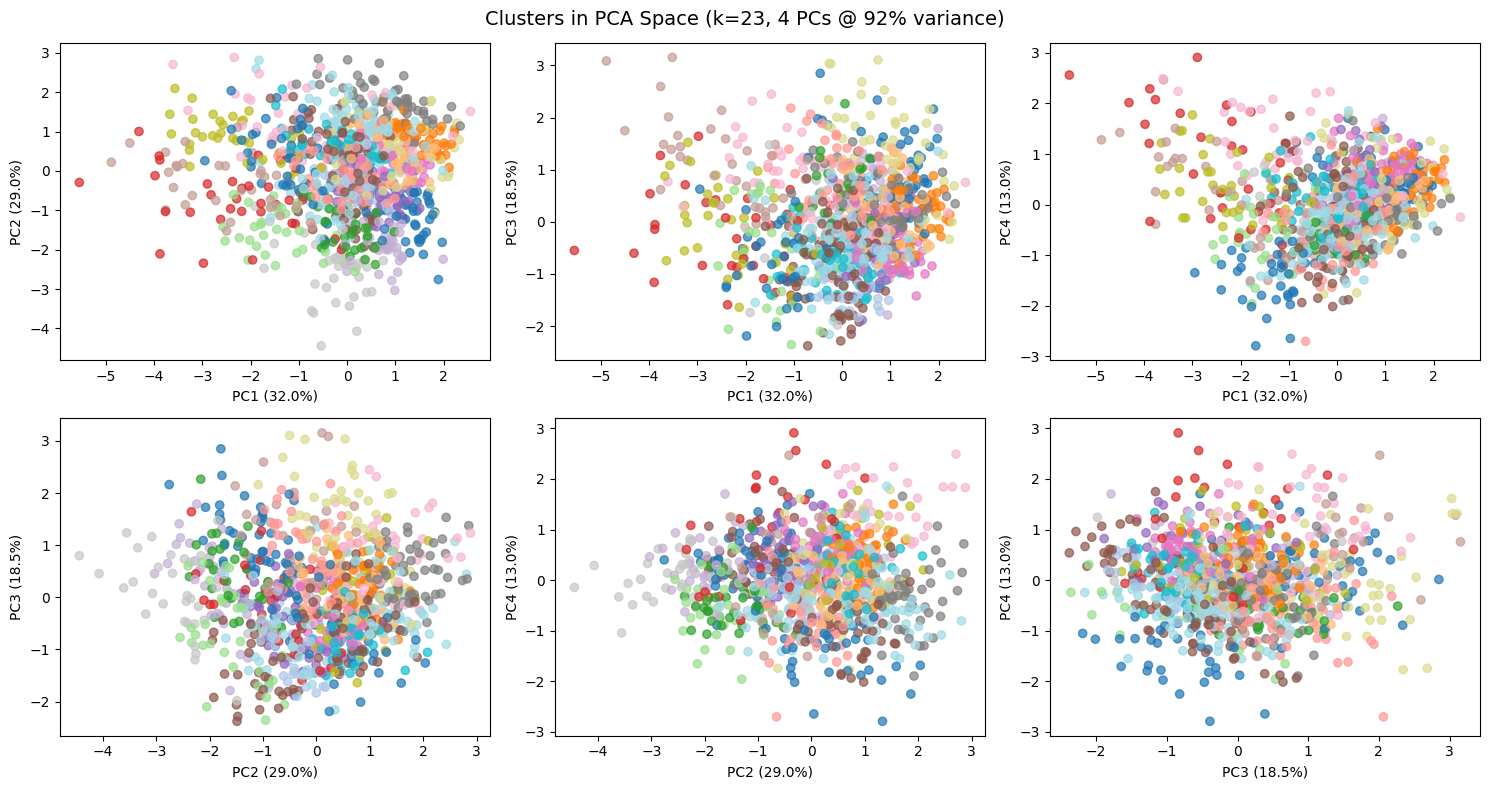

In [35]:
# Get results
results = partition_playlist(X_scaled=X_scaled, 
                             k_clusters=best_k,
                             min_size=min_size, 
                             max_size=max_size, 
                             feature_weights=FEATURE_WEIGHTS, 
                             feature_names=FEATURES
                             )

# Add cluster labels to results and plot
df_playlist_results['Cluster'] = results['clusters']
plot_cluster_pca(X_scaled, results['clusters'])

In [36]:
# Get songs in each cluster
playlists = {
    f"Playlist_{i+1}": df_playlist_results[df_playlist_results['Cluster'] == i]
    .sort_values(['BPM', 'Valence', 'Dance'])
    for i in range(results['n_clusters'])
}

print("=" * 50)
print("CLUSTER FEATURE PROFILES")
print("=" * 50)
for name, df_cluster in playlists.items():
    print(f"\n{name} (n={len(df_cluster)})")
    print(f"  Mean:  { {f: round(float(df_cluster[f].mean()), 2) for f in FEATURES} }")
    print(f"  Std:   { {f: round(float(df_cluster[f].std()), 2) for f in FEATURES} }")
    print(f"  Range: { {f: (round(float(df_cluster[f].min()), 2), round(float(df_cluster[f].max()), 2)) for f in FEATURES} }")

CLUSTER FEATURE PROFILES

Playlist_1 (n=34)
  Mean:  {'BPM': 113.79, 'Dance': 75.94, 'Energy': 49.03, 'Valence': 17.35, 'Acoustic': 8.91}
  Std:   {'BPM': 24.77, 'Dance': 8.78, 'Energy': 11.39, 'Valence': 6.28, 'Acoustic': 8.9}
  Range: {'BPM': (74.0, 178.0), 'Dance': (60.0, 96.0), 'Energy': (27.0, 76.0), 'Valence': (6.0, 33.0), 'Acoustic': (0.0, 34.0)}

Playlist_2 (n=53)
  Mean:  {'BPM': 154.02, 'Dance': 52.13, 'Energy': 83.6, 'Valence': 74.28, 'Acoustic': 5.77}
  Std:   {'BPM': 23.36, 'Dance': 5.75, 'Energy': 10.64, 'Valence': 6.78, 'Acoustic': 9.52}
  Range: {'BPM': (90.0, 205.0), 'Dance': (38.0, 63.0), 'Energy': (59.0, 99.0), 'Valence': (64.0, 89.0), 'Acoustic': (0.0, 34.0)}

Playlist_3 (n=48)
  Mean:  {'BPM': 106.12, 'Dance': 60.58, 'Energy': 78.12, 'Valence': 40.35, 'Acoustic': 4.19}
  Std:   {'BPM': 16.17, 'Dance': 3.74, 'Energy': 9.06, 'Valence': 4.26, 'Acoustic': 5.33}
  Range: {'BPM': (78.0, 140.0), 'Dance': (54.0, 69.0), 'Energy': (57.0, 94.0), 'Valence': (31.0, 48.0), 'Acou